In [1]:
import pandas as pd

#load the dataset
file_path = r"C:\Users\DURGESH\Desktop\AQI_India_reports\3b01bcb8-0b14-4abf-b6f2-c1bfd384ba69.csv"
df = pd.read_csv(file_path)

#Preview
print("Shape:", df.shape)
df.head()



Shape: (3177, 11)


,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Andhra_Pradesh,Vijayawada,"HB Colony, Vijayawada - APPCB",20-05-2025 00:00:00,16.536107,80.594233,PM10,35.0,65.0,48.0
1,India,Andhra_Pradesh,Vijayawada,"Kanuru, Vijayawada - APPCB",20-05-2025 00:00:00,16.486692,80.699436,PM2.5,NaN,NaN,NaN
2,India,Andhra_Pradesh,Vijayawada,"Kanuru, Vijayawada - APPCB",20-05-2025 00:00:00,16.486692,80.699436,PM10,NaN,NaN,NaN
3,India,Andhra_Pradesh,Vijayawada,"Kanuru, Vijayawada - APPCB",20-05-2025 00:00:00,16.486692,80.699436,NO2,NaN,NaN,NaN
4,India,Andhra_Pradesh,Vijayawada,"Kanuru, Vijayawada - APPCB",20-05-2025 00:00:00,16.486692,80.699436,SO2,NaN,NaN,NaN


In [21]:
#Step 1. Basic Overview
df.info()
df.describe()
df.columns # See column names
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3177 entries, 0 to 3176
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   country        3177 non-null   object 
 1   state          3177 non-null   object 
 2   city           3177 non-null   object 
 3   station        3177 non-null   object 
 4   last_update    3177 non-null   object 
 5   latitude       3177 non-null   float64
 6   longitude      3177 non-null   float64
 7   pollutant_id   3177 non-null   object 
 8   pollutant_min  2862 non-null   float64
 9   pollutant_max  2862 non-null   float64
 10  pollutant_avg  2862 non-null   float64
dtypes: float64(5), object(6)
memory usage: 273.2+ KB


,country,state,city,station,last_update,latitude,longitude,pollutant_id,pollutant_min,pollutant_max,pollutant_avg
0,India,Andhra_Pradesh,Vijayawada,"HB Colony, Vijayawada - APPCB",20-05-2025 00:00:00,16.536107,80.594233,PM10,35.0,65.0,48.0
1,India,Andhra_Pradesh,Vijayawada,"Kanuru, Vijayawada - APPCB",20-05-2025 00:00:00,16.486692,80.699436,PM2.5,NaN,NaN,NaN
2,India,Andhra_Pradesh,Vijayawada,"Kanuru, Vijayawada - APPCB",20-05-2025 00:00:00,16.486692,80.699436,PM10,NaN,NaN,NaN
3,India,Andhra_Pradesh,Vijayawada,"Kanuru, Vijayawada - APPCB",20-05-2025 00:00:00,16.486692,80.699436,NO2,NaN,NaN,NaN
4,India,Andhra_Pradesh,Vijayawada,"Kanuru, Vijayawada - APPCB",20-05-2025 00:00:00,16.486692,80.699436,SO2,NaN,NaN,NaN


In [3]:
#Step 2: Clean and prepare the data
#1. Convert last_update to datetime
df['last_update'] = pd.to_datetime(df['last_update'], dayfirst=True)

In [4]:
df.info()
df.head()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3177 entries, 0 to 3176
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   country        3177 non-null   object        
 1   state          3177 non-null   object        
 2   city           3177 non-null   object        
 3   station        3177 non-null   object        
 4   last_update    3177 non-null   datetime64[ns]
 5   latitude       3177 non-null   float64       
 6   longitude      3177 non-null   float64       
 7   pollutant_id   3177 non-null   object        
 8   pollutant_min  2862 non-null   float64       
 9   pollutant_max  2862 non-null   float64       
 10  pollutant_avg  2862 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(5)
memory usage: 273.2+ KB


,last_update,latitude,longitude,pollutant_min,pollutant_max,pollutant_avg
count,3177,3177.000000,3177.000000,2862.000000,2862.000000,2862.000000
mean,2025-05-20 00:00:00,22.252130,78.758905,21.937107,62.151642,37.328791
min,2025-05-20 00:00:00,8.514909,70.909168,1.000000,1.000000,1.000000
25%,2025-05-20 00:00:00,19.024390,75.387310,5.000000,16.000000,11.000000
50%,2025-05-20 00:00:00,23.041137,77.502466,13.000000,41.000000,25.000000
75%,2025-05-20 00:00:00,26.786682,80.927299,28.000000,82.000000,50.750000
max,2025-05-20 00:00:00,34.066206,94.636574,197.000000,500.000000,356.000000
std,NaN,5.511966,5.009135,26.641500,70.097895,39.085606


In [23]:
#Group by city and calculate average pollution
top_cities = df.groupby('city')['avg_pollution'].mean().sort_values(ascending=False).head(10)

KeyError: 'Column not found: avg_pollution'

In [ ]:
df.columns

In [15]:
top_cities = df.groupby('city')['pollutant_avg'].mean().sort_values(ascending=False).head(10)
print(top_cities)

city
Gurugram            108.500000
Siwan               103.714286
Amritsar             85.800000
Baddi                83.000000
Delhi                80.772908
Mandi Gobindgarh     73.857143
Yadgir               70.000000
Noida                68.333333
Muzaffarnagar        68.000000
Jalandhar            66.000000
Name: pollutant_avg, dtype: float64


C:\Users\DURGESH\AppData\Local\Temp\ipykernel_23532\2198746823.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette="Reds_r")


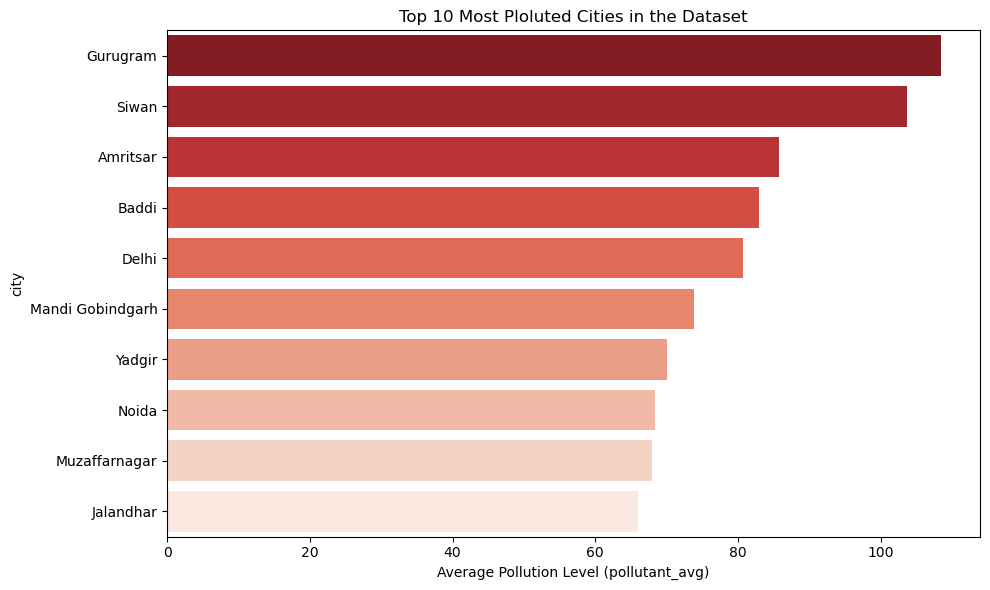

In [17]:
#Step: Viusalize This Data
#We are using a horizontal bar chart for clarity.
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x=top_cities.values, y=top_cities.index, palette="Reds_r")
plt.xlabel("Average Pollution Level (pollutant_avg)")
plt.title("Top 10 Most Ploluted Cities in the Dataset")
plt.tight_layout()
plt.show()


<Axes: ylabel='city'>

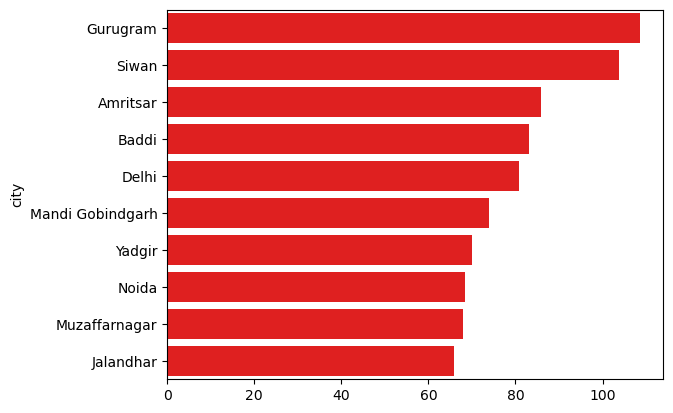

In [19]:
sns.barplot(x=top_cities.values, y=top_cities.index, color="red")

In [39]:
#Understanding how average pollution changes over time
#Group by month
monthly_trend = df.resample('M', on='last_update')['pollutant_avg'].mean()

#Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
monthly_trend.plot(marker='o')
plt.title("Monthly Average Pollution Trend")
plt.xlabel("Month")
plt.ylabel("Pollutant Average")
plt.grid(True)
plt.tight_layout()
plt.show()

KeyError: 'last_update'

In [41]:
print(df.columns)

Index(['country', 'state', 'city', 'station', 'datetime', 'latitude',
       'longitude', 'pollutant_id', 'pollutant_min', 'pollutant_max',
       'pollutant_avg'],
      dtype='object')


In [49]:
#Convert 'datetime' columns to datetime format (if not already):
df['datetime'] = pd.to_datetime(df['datetime'], dayfirst=True, errors='coerce')

In [47]:
#Group by month and claculate the average pollution:
monthly_trend = df.resample('ME', on='datetime') ['pollutant_avg'].mean()

C:\Users\DURGESH\anaconda3\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


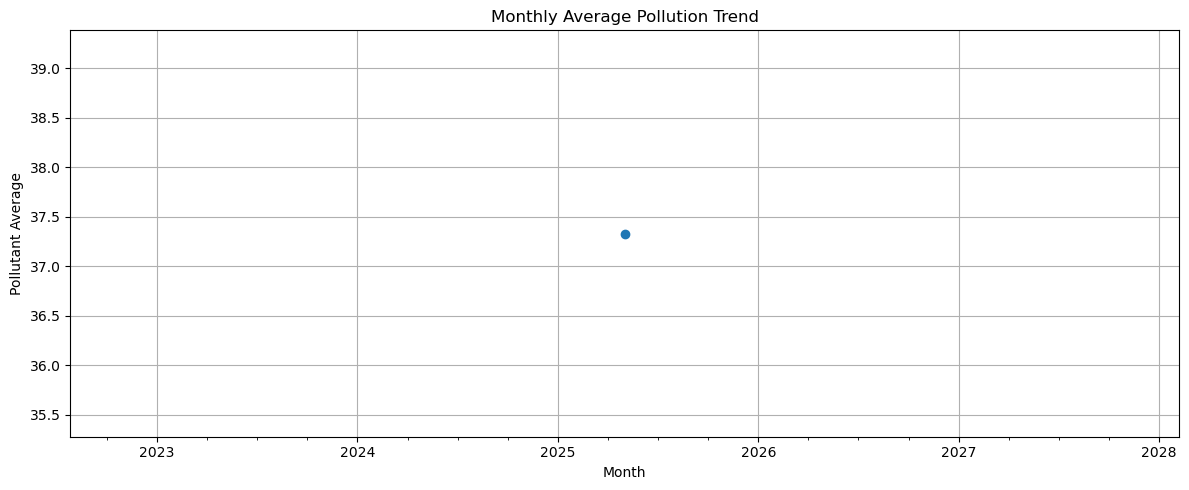

In [66]:
#Plot the trend
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
monthly_trend.plot(marker='o')
plt.title("Monthly Average Pollution Trend")
plt.xlabel("Month")
plt.ylabel("Pollutant Average")
plt.grid(True)
plt.tight_layout()
plt.show()

In [68]:
print(monthly_trend.index.min(), "->", monthly_trend.index.max())
print("Total months: ", len(monthly_trend))

2025-05-31 00:00:00 -> 2025-05-31 00:00:00
Total months:  1


C:\Users\DURGESH\anaconda3\Lib\site-packages\pandas\plotting\_matplotlib\core.py:1561: UserWarning: Attempting to set identical low and high xlims makes transformation singular; automatically expanding.
  ax.set_xlim(left, right)


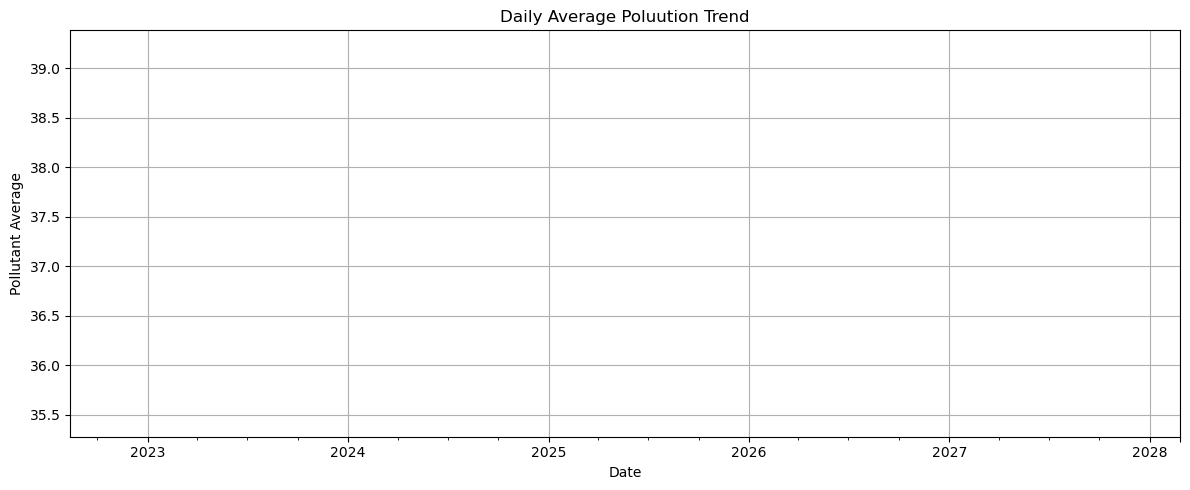

In [72]:
daily_trend  = df.resample('D', on='datetime')['pollutant_avg'].mean()

plt.figure(figsize=(12,5))
daily_trend.plot()
plt.title("Daily Average Poluution Trend")
plt.xlabel("Date")
plt.ylabel("Pollutant Average")
plt.grid(True)
plt.tight_layout()
plt.show()

In [74]:
#Checking how many unique dates are available
unique_dates = df['datetime'].dt.date.nunique()
print("Unique Dates:", unique_dates)

# View frequency of data per date (optional)
print(df['datetime'].dt.date.value_counts().sort_index())

Unique Dates: 1
datetime
2025-05-20    3177
Name: count, dtype: int64


AttributeError: Rectangle.set() got an unexpected keyword argument 'palettte'

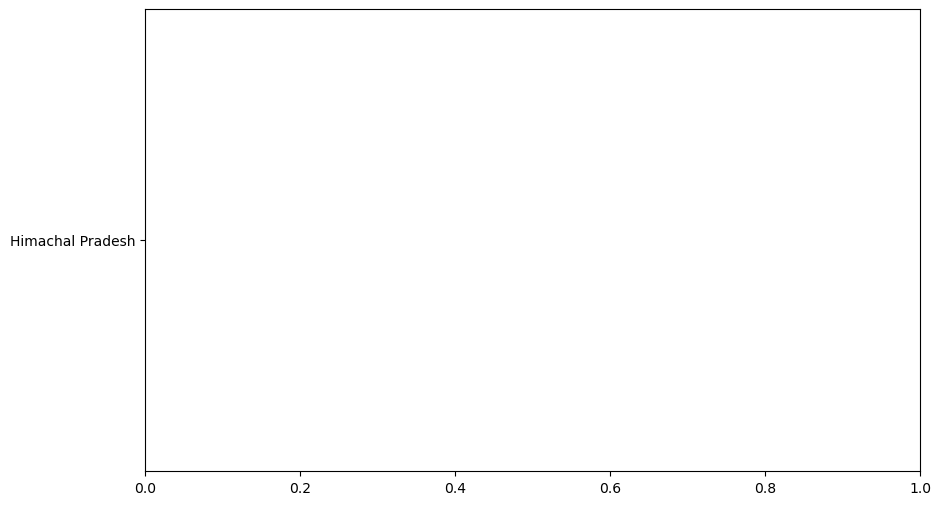

In [82]:
top_states = df.groupby('state')['pollutant_avg'].mean().sort_values(ascending=False).head(10)

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x=top_states.values, y=top_states.index, palettte="Oranges_r")
plt.title("Top 10 Most Polluted States (20 May 2025)")
plt.xlabel("Average Pollution Level")
plt.tight_layout()
plt.show()            
            

Top Polluted States:
 state
Himachal Pradesh    83.000000
Delhi               80.772908
Haryana             74.454545
Chandigarh          64.111111
Punjab              63.375000
Jharkhand           56.666667
Uttar_Pradesh       43.223464
Uttarakhand         41.466667
Madhya Pradesh      39.766667
Rajasthan           39.074194
Name: pollutant_avg, dtype: float64


C:\Users\DURGESH\AppData\Local\Temp\ipykernel_23532\3236587627.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.values, y=top_states.index, palette="Oranges_r")


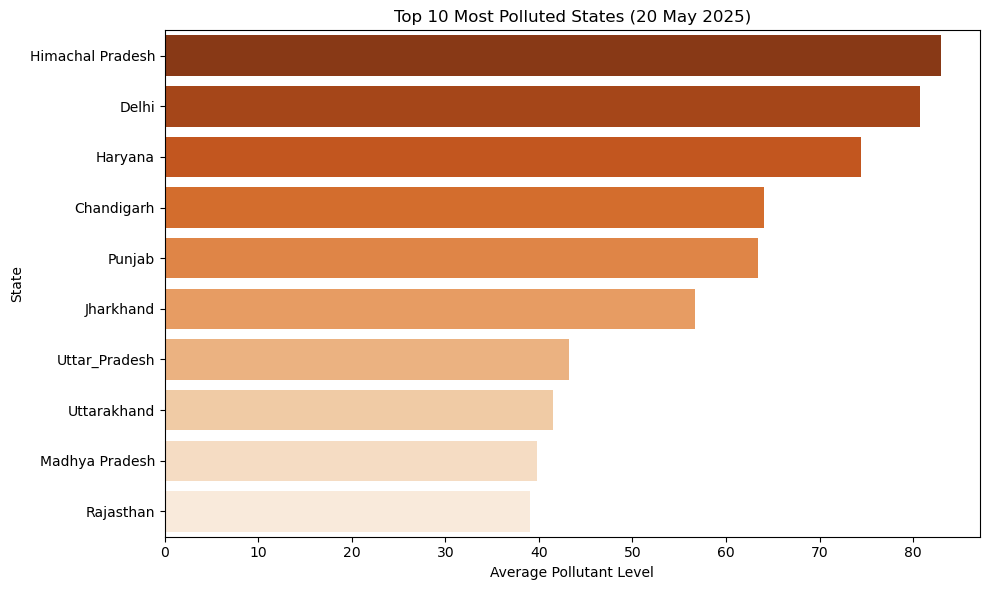

In [96]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Group and sort states by average pollution
top_states = df.groupby('state')['pollutant_avg'].mean().sort_values(ascending=False).head(10)

#Print to verify
top_states = df.groupby('state')['pollutant_avg'].mean().sort_values(ascending=False).head(10)

#Print to verify
print("Top Polluted States:\n", top_states)

#Plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_states.values, y=top_states.index, palette="Oranges_r")
plt.title("Top 10 Most Polluted States (20 May 2025)")
plt.xlabel("Average Pollutant Level")
plt.ylabel("State")
plt.tight_layout()
plt.show()

In [112]:
#Step 3. Feature Engineering
#Extract day, month, weekday from the datetime
df['day'] = df['datetime'].dt.day
df['month'] = df['datetime'].dt.month
df['weekday'] = df['datetime'].dt.day_name()

# Create AQI category based on pollutant_avg (if this is acting as AQI)
def categorize_aqi(value):
    if value <= 50:
        return 'Good'
    elif value <= 100:
        return 'Satisfactory'
    elif value <= 200:
        return 'Moderate'
    elif value <= 300:
        return 'Poor'
    elif value <= 400:
        return 'Very Poor'
    else:
        return 'Severe'

df['aqi_category'] = df['pollutant_avg'].apply(categorize_aqi)

#Preview
df[['datetime', 'day', 'month', 'weekday', 'pollutant_avg', 'aqi_category']].head()
        


,datetime,day,month,weekday,pollutant_avg,aqi_category
0,2025-05-20,20,5,Tuesday,48.0,Good
1,2025-05-20,20,5,Tuesday,NaN,Severe
2,2025-05-20,20,5,Tuesday,NaN,Severe
3,2025-05-20,20,5,Tuesday,NaN,Severe
4,2025-05-20,20,5,Tuesday,NaN,Severe


In [114]:
#Data Integrity Checks(important for scoring on "consistency across cities, pollutants, and timeframes").
#1. Check for missing or inconsistent geographic entries
print("Unique States:", df['state'].nunique())
print("Unique States:", df['city'].nunique())
print("Unique States:", df['station'].nunique())

#Check if any cities have missing state info
print(df[df['state'].isnull()][['city', 'station']])


Unique States: 31
Unique States: 243
Unique States: 478
Empty DataFrame
Columns: [city, station]
Index: []


In [120]:
#2. Check consistency of pollutant values
#(Ensure pollutant_min <= pollutant_avg <= pollutant_max)
inconsistent_rows = df[
(df['pollutant_min'] > df['pollutant_avg']) |
(df['pollutant_avg'] > df['pollutant_max'])
]

print("Inconsistent pollutant rows:", len(inconsistent_rows))


Inconsistent pollutant rows: 0


In [122]:
#3. Check for duplicate records(e.g., same city, station, datetime)
duplicates = df.duplicated(subset=['city', 'station', 'datetime', 'pollutant_avg']).sum()
print("Duplicate records found:", duplicates)

Duplicate records found: 291


In [124]:
#4.Check valid date range
print("Date timeframe:", df['datetime'].min(), "->", df['datetime'].max())

Date timeframe: 2025-05-20 00:00:00 -> 2025-05-20 00:00:00


In [128]:
#Drop invalid rows(if found)
df = df.drop_duplicates(subset=['city', 'station', 'datetime', 'pollutant_avg'])

In [132]:
df = df.drop_duplicates(subset=['city', 'station', 'datetime', 'pollutant_avg'])
print("After dropping, shape:", df.shape)

After dropping, shape: (2886, 15)


In [144]:
#STEP5. Summary statistics of pollutant columns
df[['pollutant_min', 'pollutant_max', 'pollutant_avg']].describe()
   

,pollutant_min,pollutant_max,pollutant_avg
count,2772.000000,2772.000000,2772.000000
mean,22.290043,63.231962,37.948413
std,26.928342,70.809298,39.452504
min,1.000000,1.000000,1.000000
25%,5.000000,16.000000,11.000000
50%,13.000000,42.000000,26.000000
75%,29.000000,83.250000,51.000000
max,197.000000,500.000000,356.000000


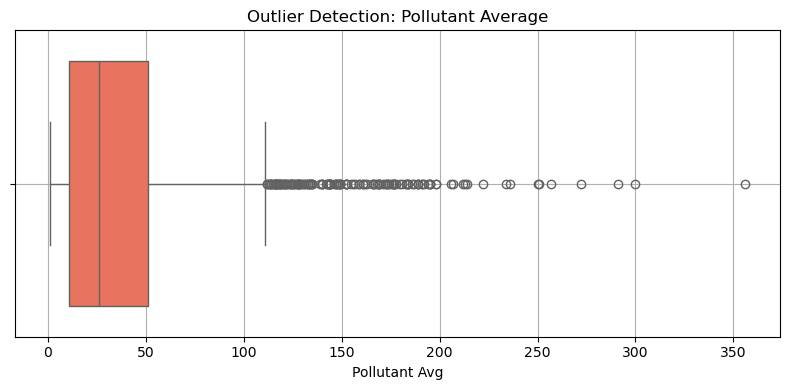

In [148]:
#2.Detect outliers using a boxplot
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 4))
sns.boxplot(x=df['pollutant_avg'], color='tomato')
plt.title("Outlier Detection: Pollutant Average")
plt.xlabel("Pollutant Avg")
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\DURGESH\AppData\Local\Temp\ipykernel_23532\2387608285.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cities.values, y=top_cities.index, palette="Reds_r")


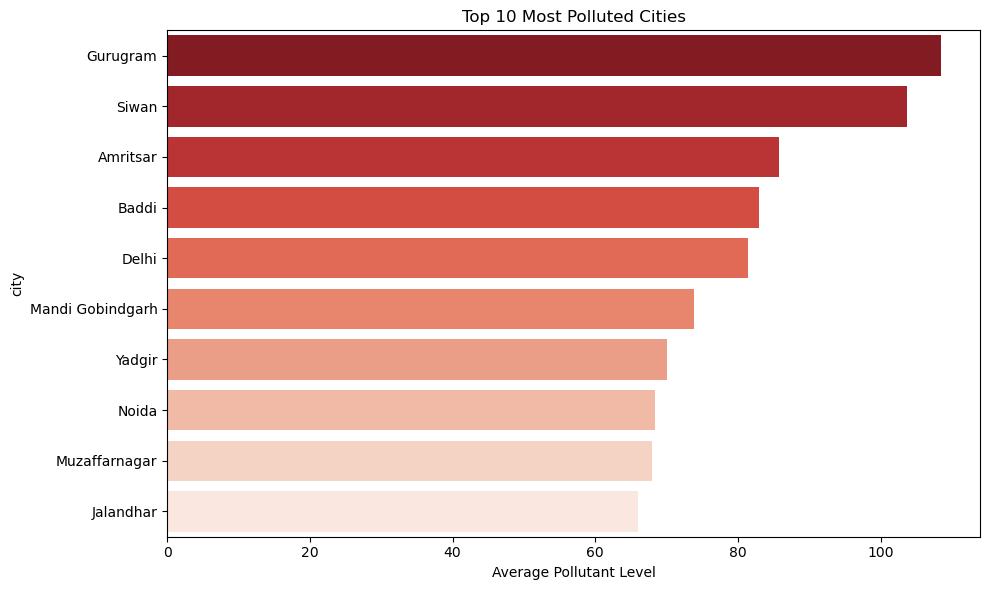

In [152]:
#3. Spot pollution patterns by city (Top 10)
top_cities = df.groupby('city')['pollutant_avg'].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=top_cities.values, y=top_cities.index, palette="Reds_r")
plt.title("Top 10 Most Polluted Cities")
plt.xlabel("Average Pollutant Level")
plt.tight_layout()
plt.show()


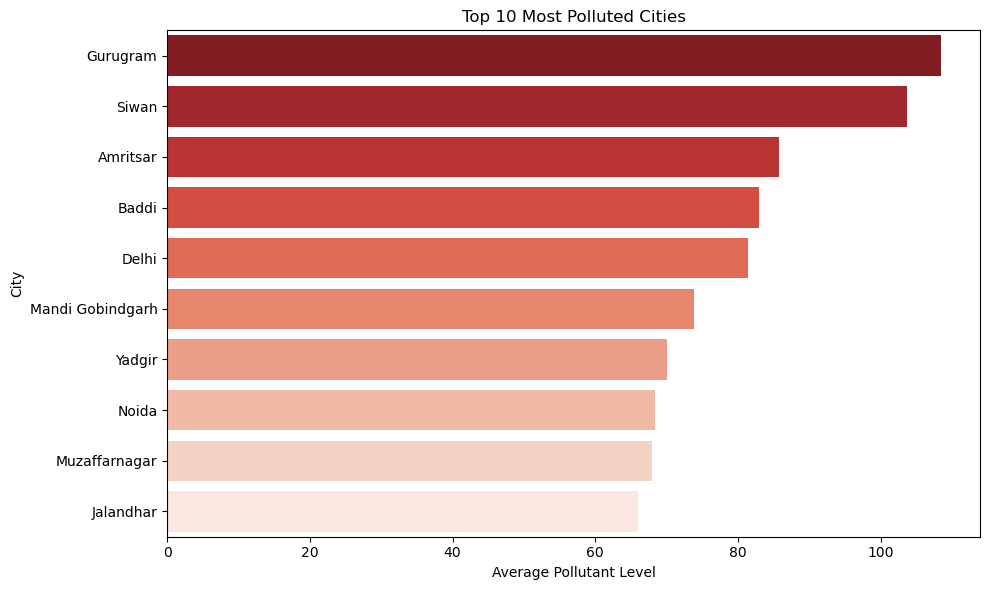

In [158]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.barplot(x=top_cities.values, y=top_cities.index, hue=top_cities.index, palette="Reds_r", legend=False)
plt.title("Top 10 Most Polluted Cities")
plt.xlabel("Average Pollutant Level")
plt.ylabel("City")
plt.tight_layout()
plt.show()